<a href="https://colab.research.google.com/github/RixzFahad/Machine-Learning/blob/main/Knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install mlxtend==0.22.0
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [42]:
df = pd.read_csv("/content/ushape.csv", header=None)
df.head()
# This ushape data is a masked data means we dont have proper column names so there is no header
# index column 2 is a target variable based on the values it is a binary classification problem
# add a new columns to the dataframe

,0,1,2
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [43]:
#Add The New Columns.
df.columns = ["X", "Y", "Class"]
df.head()

,X,Y,Class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [44]:
#Chec Total Value
df.shape

(100, 3)

In [45]:
#Check the null value
df.isnull().sum()

,0
X,0
Y,0
Class,0


In [46]:
#Check the data Type
df.dtypes

,0
X,float64
Y,float64
Class,float64




*   **There Is No Null Value's**
*   **Check The Duplicates If There are Duplicates Then Drop Them**
*   **Check The Dtypes And Changes The Class DTtype To Integer**
*   **No Need To Encode The Data Beacause Data Are Numerical**



***Define Features And Target Value's***

In [47]:
# convert the data type of class from float to integer
# use the "astype()"
x = df[['X', 'Y']].values
y = df['Class'].astype(int).values

***Split The Data***

In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((70, 2), (30, 2), (70,), (30,))

In [49]:
# what is feature engineering?
# feature engineering is the process of transforming raw data into meaningful features
# so that machine learning models can understand patterns better and give accurate predictions

# why we use it?
# raw data is often not in a proper format for models
# it may contain missing values, noise, or non-linear patterns
# feature engineering helps to clean, transform, and enhance the data

# what we do in feature engineering?
# create new features (new columns from existing data)
# transform existing features (log, square, normalization, scaling)
# encode categorical data into numerical form (label encoding, one-hot encoding)
# select important features and remove irrelevant ones
# handle missing values (fill or drop)
# scale the data for better model performance

# example:
# converting non-linear data into linear using transformation
df['x2'] = df['X'] ** 2

# result:
# better features -> better learning -> better model accuracy

***Scale The Data***

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#Do We Need To Scale Just Training Or Entire Data??
xtrain = scaler.fit_transform(x_train)
xtest = scaler.transform(x_test)
#Scalling Can BE Done On XTrain OR XTest DAta.

# ***Task Jar***

**Here in this test case we predict the binary classification values**

# ***Model Jar***

In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)

    # validate the model to find best k using only training data
    cv_score = np.mean(cross_val_score(knn, x_train, y_train, cv=10))

    print("Kvalue", i,
          "train_score", knn.score(x_train, y_train),
          "cross_val_score", cv_score)

Kvalue 1 train_score 1.0 cross_val_score 0.8857142857142858
Kvalue 2 train_score 0.9285714285714286 cross_val_score 0.8714285714285713
Kvalue 3 train_score 0.9571428571428572 cross_val_score 0.9285714285714286
Kvalue 4 train_score 0.9428571428571428 cross_val_score 0.9285714285714286
Kvalue 5 train_score 0.9428571428571428 cross_val_score 0.9285714285714286
Kvalue 6 train_score 0.9285714285714286 cross_val_score 0.9000000000000001
Kvalue 7 train_score 0.9428571428571428 cross_val_score 0.9285714285714286
Kvalue 8 train_score 0.9142857142857143 cross_val_score 0.9000000000000001
Kvalue 9 train_score 0.9285714285714286 cross_val_score 0.9285714285714286
Kvalue 10 train_score 0.9142857142857143 cross_val_score 0.9285714285714286


In [52]:
#why we are getting the diffrent cross validation sore for each k model-?
#Bacause instead of learning from training data my ml model byhotiing the data points where it leads to a "Overfitting And Underfitting" Problems

#What Is Overfitting?
#When There Is Gain In training score in one model and gain test score in another model then we supposed to call it overfitting>


#What Is Underfitting?
#When  there is failure in both training and testing scores model leads underftting models
# Q1. To overcome underfitting and overfitting what we need to do?

# UNDERFITTING (model too simple)
# increase model complexity (e.g., increase K features, use better model)
# add more relevant features (feature engineering)
# reduce regularization
# train model longer (if applicable)

# OVERFITTING (model too complex)
# reduce model complexity (e.g., increase K in KNN)
# apply regularization (L1/L2)
# use cross-validation
# remove noisy or irrelevant features
# use more training data
# apply techniques like pruning (for trees)

# GENERAL SOLUTION
# use cross-validation to find best hyperparameters
# balance bias and variance for optimal performance


In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [54]:
#Prdict the Model On X_Test
y_pred = knn.predict(x_test)

y_pred

array([0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0])

# ***Evaluate The Model***

In [55]:
from sklearn.metrics import f1_score, roc_auc_score
auroc = roc_auc_score(y_test, y_pred)
print(auroc)


1.0


In [58]:
f1 = f1_score(y_test, y_pred)
print(f1)

1.0


**Visualize The Best K Value**

In [56]:
from mlxtend.plotting import plot_decision_regions

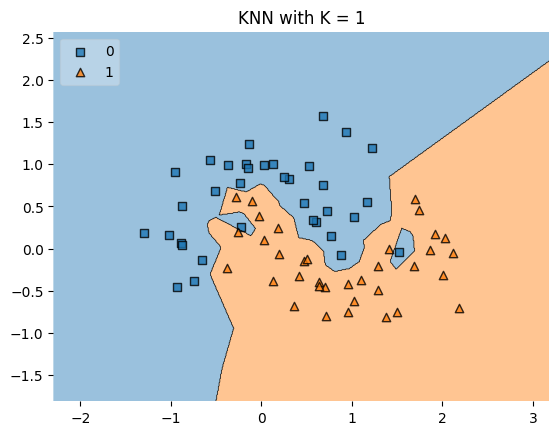

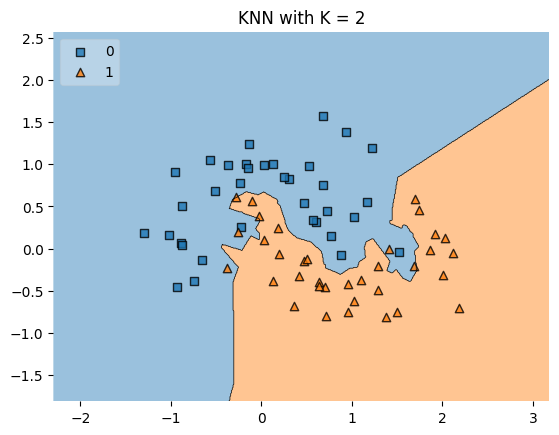

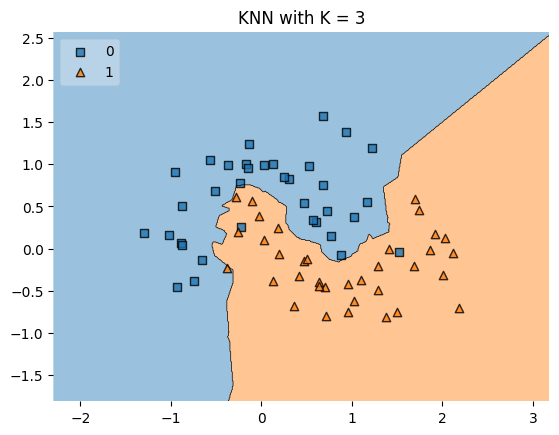

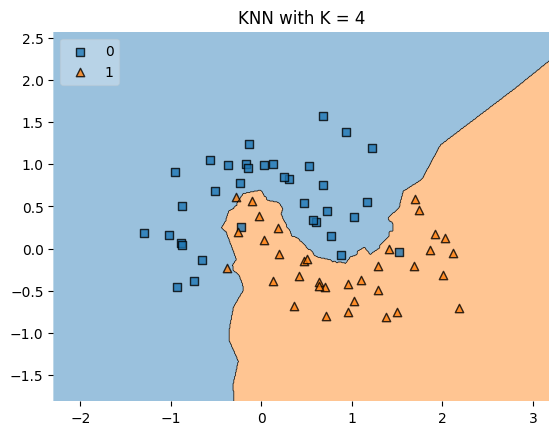

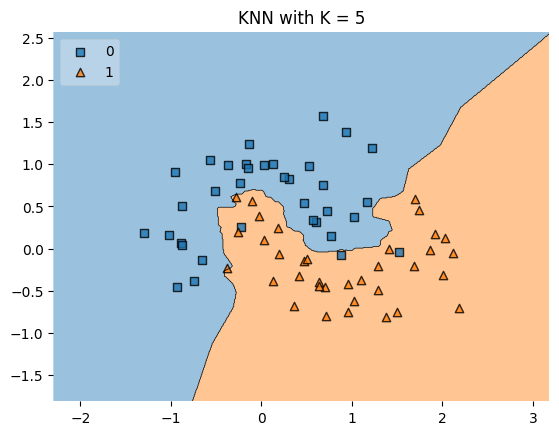

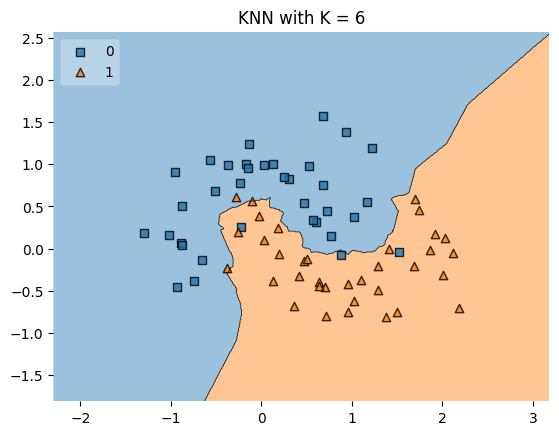

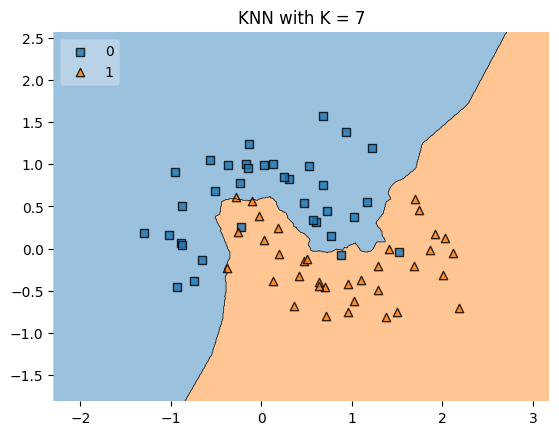

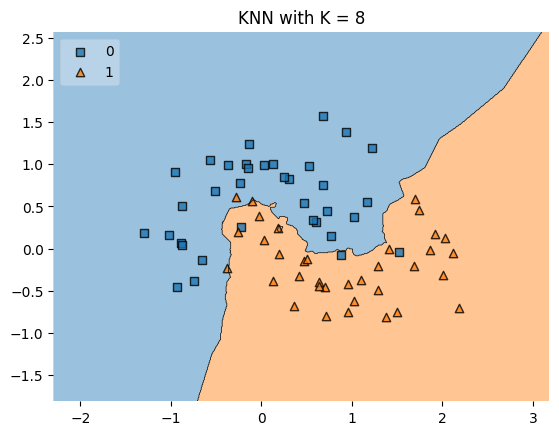

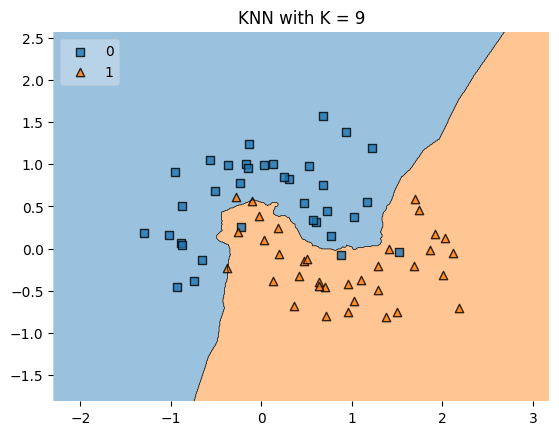

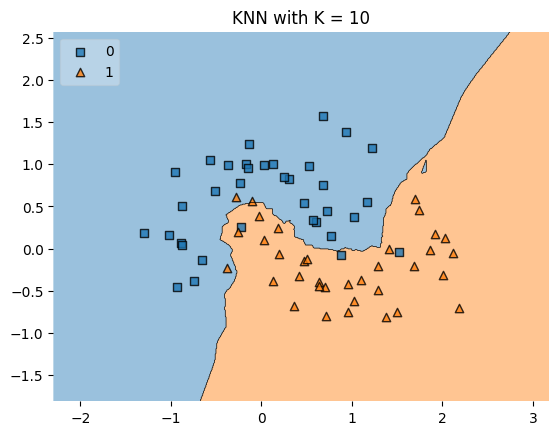

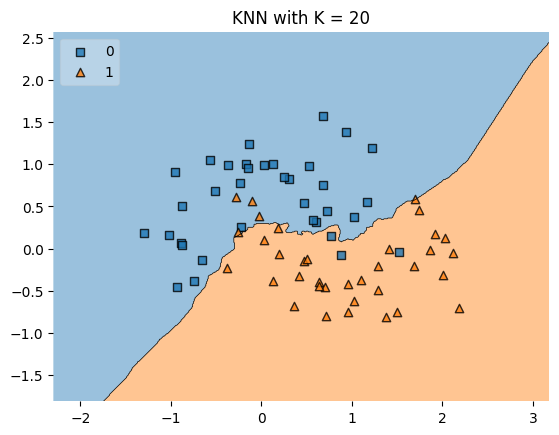

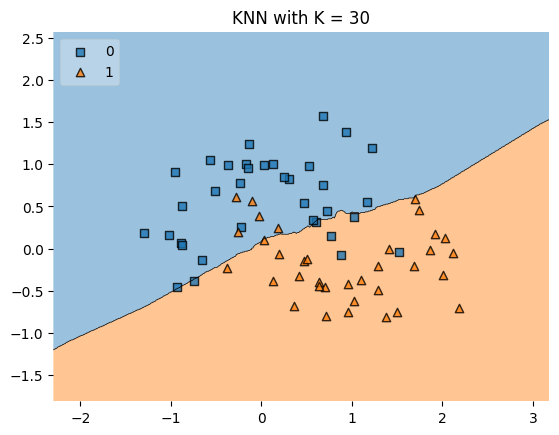

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# make sure X has only 2 features
X = x_train[:, :2]   # take first 2 features only
y = y_train

for i in [1,2,3,4,5,6,7,8,9,10,20,30]:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X, y)

    plot_decision_regions(X, y, clf=knn, legend=2)
    plt.title("KNN with K = " + str(i))
    plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from mlxtend.plotting import plot_decision_

In [ ]:
# ================================
# 🔥 KNN, ML Concepts – Quick Notes
# ================================

# ✅ Q1: How can we avoid overfitting and underfitting in KNN?
# → By choosing the optimal value of "K"
#   - Small K → Overfitting (model memorizes data)
#   - Large K → Underfitting (model too general)
#   - Use techniques like Cross Validation to find best K

# --------------------------------

# ✅ Q2: What is Cross Validation?
# → A smart way to evaluate model performance
# → It splits training data into multiple parts (folds)
# → Trains and tests model multiple times
# → Final score = average of all runs
# → Gives more reliable performance than single train-test split

# --------------------------------

# ✅ Q3: What is Classification?
# → Predicting categorical output
# → Example: Yes/No, Spam/Not Spam, Apple/Orange

# --------------------------------

# ✅ Q4: What is Regression?
# → Predicting continuous numerical values
# → Example: Price, Salary, Temperature

# --------------------------------

# ✅ Q5: What is "K" in KNN?
# → "K" is a hyperparameter
# → It defines number of nearest neighbors considered for prediction

# --------------------------------

# ✅ Q6: What is "y" in Linear Regression?
# → "y" is the target variable (actual output we want to predict)

# --------------------------------

# ✅ Q7: What is "y" in Logistic Regression?
# → "y" represents predicted probability (value between 0 and 1)

# --------------------------------

# ✅ Q8: Why is Logistic Regression used for Classification?
# → Because it predicts probability (0 to 1)
# → Then we convert probability into class using threshold

# --------------------------------

# ✅ Q9: How to convert numerical output into categories in Logistic Regression?
# → By applying a threshold (usually 0.5)

# Example:
# if probability >= 0.5 → Class = 1
# if probability < 0.5  → Class = 0

# --------------------------------

# 🎯 Final Insight:
# ML is not just about models
# → It's about choosing right parameters, evaluation, and understanding data